In [5]:
import numpy as np
import pymc as pm
import arviz as az
import numpy as np


import matplotlib.pyplot as plt

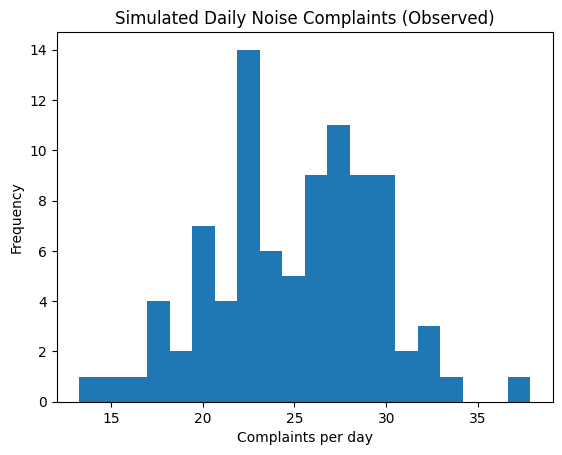

In [6]:


rng = np.random.default_rng(42)

# True (unknown) parameters
true_mu = 25      # avg daily noise complaints
true_sigma = 6    # day-to-day variability

# Simulated observed data
n_days = 90
complaints = rng.normal(true_mu, true_sigma, size=n_days)

# Counts can't be negative
complaints = np.clip(complaints, 0, None)

plt.hist(complaints, bins=20)
plt.title("Simulated Daily Noise Complaints (Observed)")
plt.xlabel("Complaints per day")
plt.ylabel("Frequency")
plt.show()


In [7]:
# -----------------------
# 2) Define a Normal model
# -----------------------

with pm.Model() as noise_model:

    # Priors (weakly informative)
    mu = pm.Normal("mu", mu=20, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Likelihood
    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=complaints
    )

    # Sample posterior
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )




Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 29 seconds.


In [8]:
az.summary(idata, var_names=["mu", "sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,25.043,0.486,24.110,25.957,0.006,0.006,7240.0,4926.0,1.0
sigma,4.585,0.351,3.911,5.228,0.004,0.004,6856.0,5281.0,1.0


In [10]:
with noise_model:
    ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        random_seed=42
    )




Sampling: [y_obs]


Output()

         mean     sd  hdi_3%  hdi_97%
mu     25.043  0.486  24.110   25.957
sigma   4.585  0.351   3.911    5.228


AttributeError: module 'arviz' has no attribute 'from_pymc'

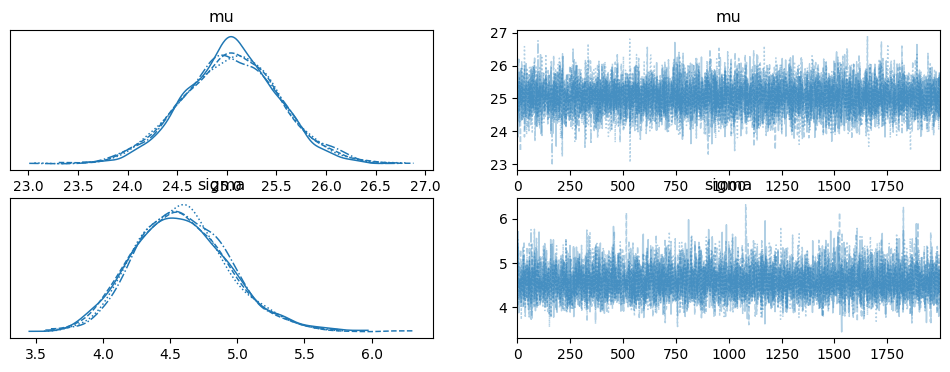

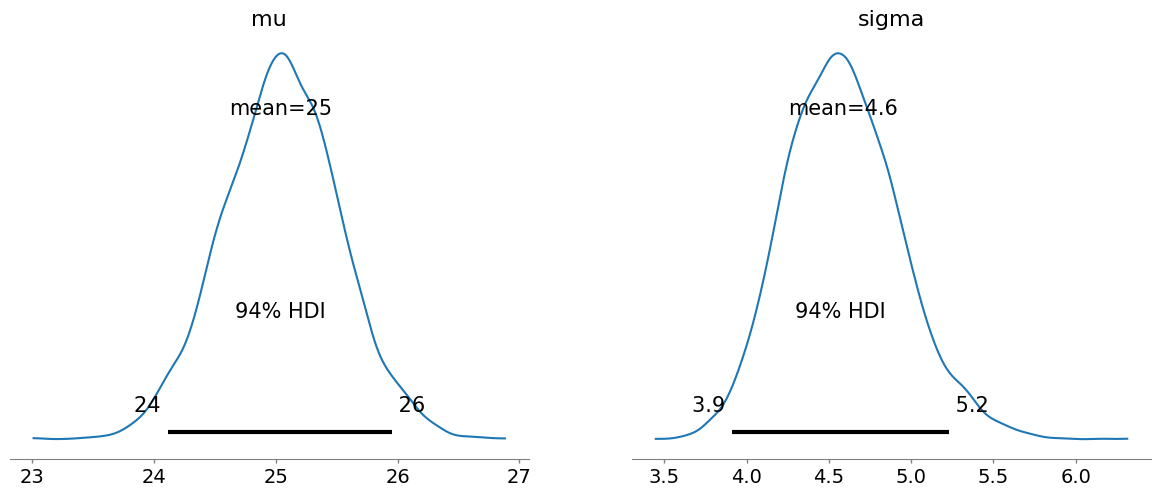

In [11]:
# -----------------------
# 3) Inspect results
# -----------------------
print(az.summary(idata, var_names=["mu", "sigma"], kind="stats"))

az.plot_trace(idata, var_names=["mu", "sigma"])
az.plot_posterior(idata, var_names=["mu", "sigma"])

# Optional: posterior predictive check
az.plot_ppc(az.from_pymc(posterior_predictive=ppc, model=model), group="posterior_predictive")


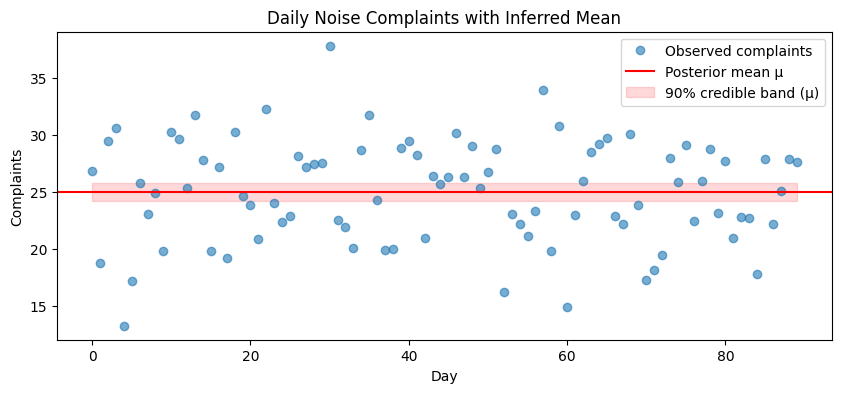

In [12]:
import matplotlib.pyplot as plt
import numpy as np

mu_post = idata.posterior["mu"].values.flatten()

plt.figure(figsize=(10,4))
plt.plot(complaints, marker="o", linestyle="", alpha=0.6, label="Observed complaints")
plt.axhline(mu_post.mean(), color="red", label="Posterior mean μ")
plt.fill_between(
    range(len(complaints)),
    np.percentile(mu_post, 5),
    np.percentile(mu_post, 95),
    color="red",
    alpha=0.15,
    label="90% credible band (μ)"
)
plt.title("Daily Noise Complaints with Inferred Mean")
plt.xlabel("Day")
plt.ylabel("Complaints")
plt.legend()
plt.show()
